In [ ]:
# ========================================================
# ST2195 Coursework
# Name: Stacia Tan Rui Shi
# Student ID: 240509602
# ========================================================

In [1]:
#Part 2a
##What are the best times and days of the week to minimise delays each year?
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np
#using the same db from R
conn = sqlite3.connect("airline_coursework.db")
#seeing if it connected to db
test_query = "SELECT Year, Month, DayOfWeek, UniqueCarrier FROM ontime LIMIT 5"
test_df = pd.read_sql_query(test_query, conn)
print("Connection success hell yea")
print(test_df)

Connection success hell yea
   Year  Month  DayOfWeek UniqueCarrier
0  2002      1          7            US
1  2002      1          1            US
2  2002      1          2            US
3  2002      1          3            US
4  2002      1          4            US


In [2]:
#looking for delays so remove cancelled & diverted
conn.text_factory = lambda b: b.decode(errors='ignore')
query = """
SELECT Year, Month, DayOfWeek, CRSDepTime, ArrDelay, TailNum
FROM ontime
WHERE Cancelled = 0 AND diverted = 0 
"""
delay_df = pd.read_sql_query(query, conn)
conn.text_factory = str

In [3]:
#dividing hour from 2359 to 23.59 then rounding off so we can get 
#0-23 hours on the chart! 
#using departure time as hour because people are seeing when to book their flights to 
#avoid delays = arrival delay 
delay_df['Hour'] = np.floor(delay_df['CRSDepTime'] / 100)

In [4]:
#classifying delay
bins = [-np.inf, 15, 59, 119, np.inf]
labels = ["on_time", "minor_delay", "moderate_delay", "severe_delay"]
delay_df['delay_classification'] = pd.cut(delay_df['ArrDelay'], bins=bins, labels=labels)

#day and month mapping
days_map = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday", 7: "Sunday"}
months_map = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}
delay_df['dayofweekstring'] = delay_df['DayOfWeek'].map(days_map)       
delay_df['monthstring'] = delay_df['Month'].map(months_map)
#ensure order 
delay_df['dayofweekstring'] = pd.Categorical(delay_df['dayofweekstring'], categories=list(days_map.values()), ordered = True)
delay_df['monthstring'] = pd.Categorical(delay_df['monthstring'], categories=list(months_map.values()), ordered = True)
print("Data cleaning = complete, First 5 rows:")
print(delay_df[['monthstring','dayofweekstring','Hour', 'ArrDelay','delay_classification','TailNum']].head())


Data cleaning = complete, First 5 rows:
  monthstring dayofweekstring  Hour  ArrDelay delay_classification TailNum
0     January          Sunday  22.0     -11.0              on_time    N709
1     January          Monday  22.0      -6.0              on_time    N733
2     January         Tuesday  22.0     -11.0              on_time    N758
3     January       Wednesday  22.0     -13.0              on_time    N707
4     January        Thursday  22.0      -8.0              on_time    N713


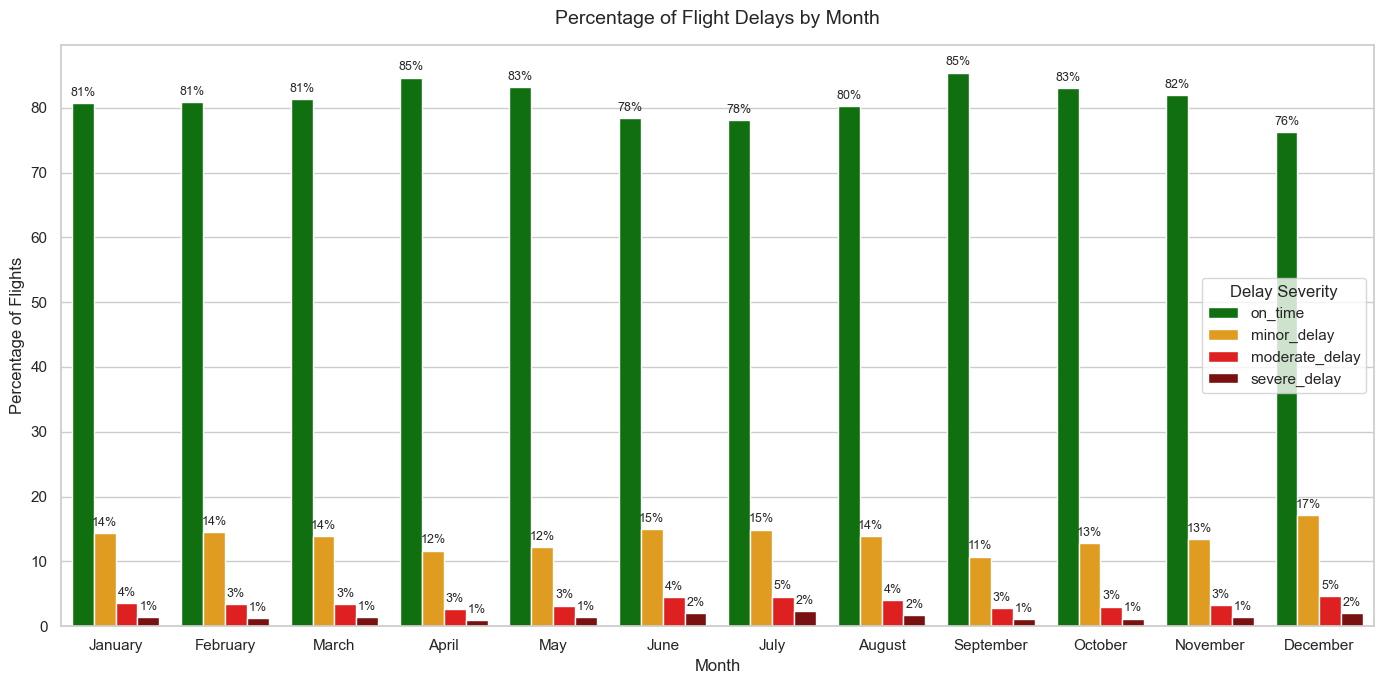

In [24]:
#group by month and classification 
#drop missing data, group it by month and delay
#observed = False : even if its 0, still show 
#% of flight delays by MONTH 
month_counts = delay_df.dropna(subset=['delay_classification', 'monthstring']) \
    .groupby(['monthstring', 'delay_classification'], observed=False).size().reset_index(name='Count')
month_totals = month_counts.groupby('monthstring', observed = False)['Count'].transform('sum')
month_counts['Percentage'] = month_counts['Count'] / month_totals * 100
#plotin
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
color_palette = {"on_time": "green", "minor_delay": "orange", "moderate_delay": "red", "severe_delay": "darkred"}
ax = sns.barplot(
    data=month_counts, 
    x='monthstring', 
    y='Percentage', 
    hue='delay_classification', 
    palette=color_palette
)
for container in ax.containers:
    labels = [f"{val:.0f}%" if val > 0 else "" for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, size=9)
plt.title("Percentage of Flight Delays by Month", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Percentage of Flights", fontsize=12)
plt.legend(title="Delay Severity")
plt.tight_layout()

plt.show()

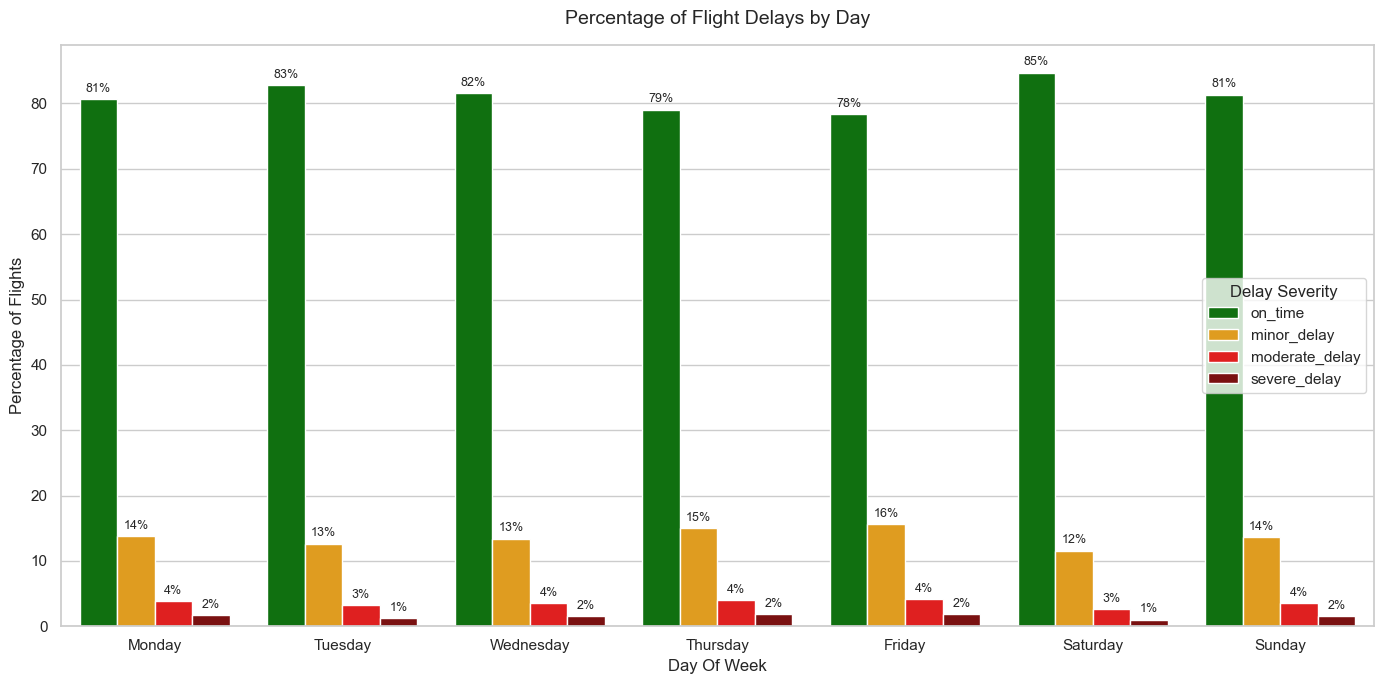

In [26]:
#% of flight delays by day
day_counts = delay_df.dropna(subset=['delay_classification', 'dayofweekstring']) \
    .groupby(['dayofweekstring', 'delay_classification'], observed=False).size().reset_index(name='Count')
day_totals = day_counts.groupby('dayofweekstring', observed = False)['Count'].transform('sum')
day_counts['Percentage'] = day_counts['Count'] / day_totals * 100
#plotin
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=day_counts, 
    x='dayofweekstring', 
    y='Percentage', 
    hue='delay_classification', 
    palette=color_palette
)
for container in ax.containers:
    labels = [f"{val:.0f}%" if val > 0 else "" for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, size=9)
plt.title("Percentage of Flight Delays by Day", fontsize=14, pad=15)
plt.xlabel("Day Of Week", fontsize=12)
plt.ylabel("Percentage of Flights", fontsize=12)
plt.legend(title="Delay Severity")
plt.tight_layout()

plt.show()

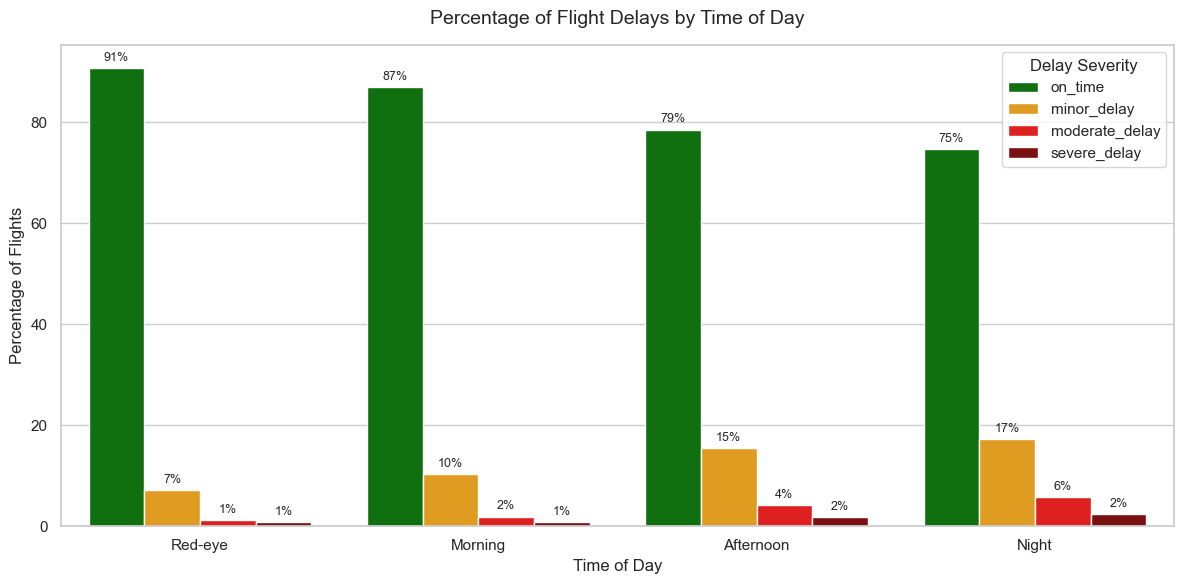

In [35]:
##% of flight delays by time of day
conditions = [
    (delay_df['Hour'] >= 0) & (delay_df['Hour']<= 5) | (delay_df['Hour']== 24),
    (delay_df['Hour'] >5) & (delay_df['Hour'] <=11),
    (delay_df['Hour'] >= 12) & (delay_df['Hour'] <=17),
    (delay_df['Hour'] >=18) & (delay_df['Hour'] <=23),
]
choices = ["Red-eye", "Morning", "Afternoon", "Night"]
delay_df['Time_Of_Day'] = np.select(conditions, choices, default = "Unknown")
delay_df['Time_Of_Day'] = pd.Categorical(delay_df['Time_Of_Day'], categories=choices, ordered=True)
time_counts = delay_df.dropna(subset=['delay_classification', 'Time_Of_Day']) \
    .groupby(['Time_Of_Day', 'delay_classification'], observed = False).size().reset_index(name='Count')
time_totals = time_counts.groupby('Time_Of_Day', observed=False)['Count'].transform('sum')
time_counts['Percentage'] = (time_counts['Count'] / time_totals) * 100
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data = time_counts,
    x='Time_Of_Day',
    y='Percentage',
    hue='delay_classification',
    palette=color_palette
)
for container in ax.containers:
    labels = [f"{val:.0f}%" if val > 0 else "" for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, size =9)
    plt.title("Percentage of Flight Delays by Time of Day", fontsize=14, pad=15)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Percentage of Flights", fontsize=12)
plt.legend(title="Delay Severity")
plt.tight_layout()
plt.show()

/var/folders/3s/18tyyckd7192fv63qt_316j80000gn/T/ipykernel_87980/240080753.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = heat_df.groupby(['dayofweekstring','Hour'])['ArrDelay'].mean().reset_index()


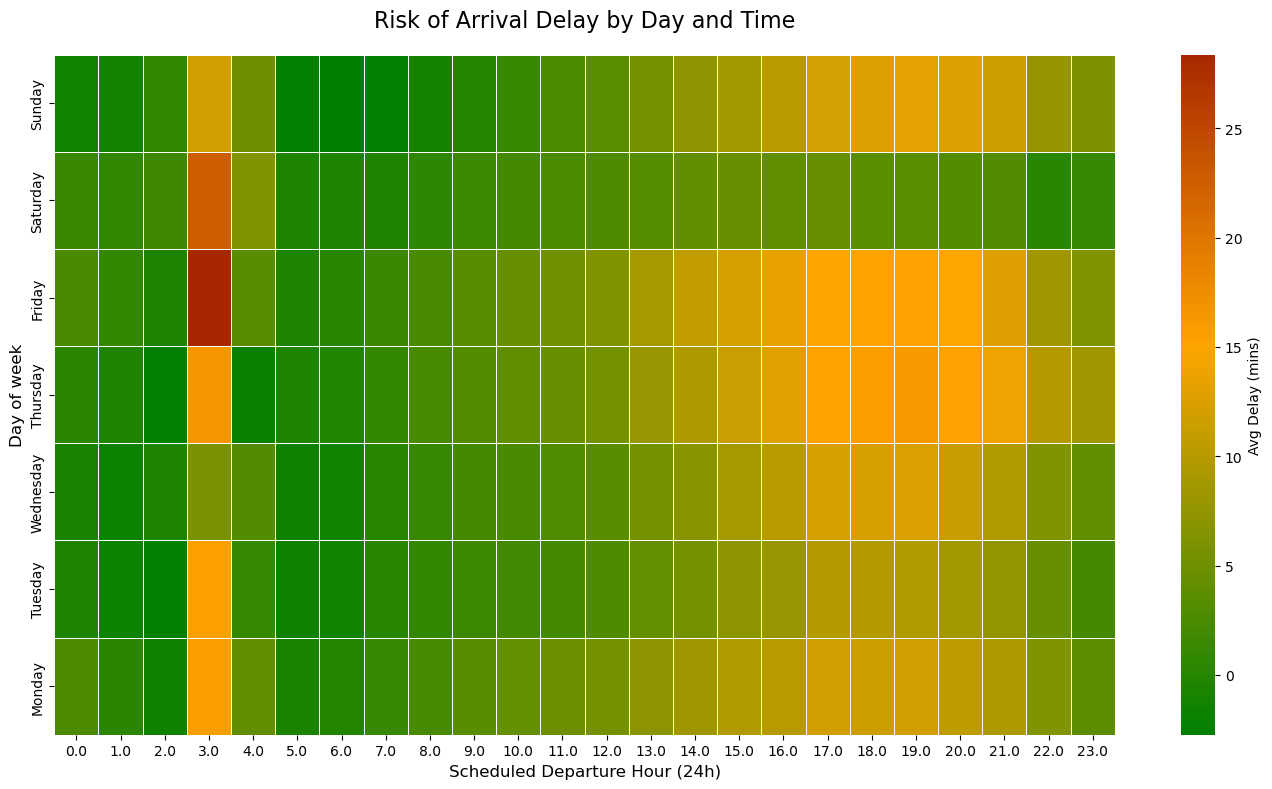

In [6]:
##2b 
from matplotlib.colors import LinearSegmentedColormap
heat_df = delay_df.dropna(subset=['delay_classification','Hour','dayofweekstring']).copy()
#replace all 24xx to 00xx 
heat_df['Hour'] = heat_df['Hour'].replace(24,0)
heatmap_data = heat_df.groupby(['dayofweekstring','Hour'])['ArrDelay'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='dayofweekstring',columns='Hour', values='ArrDelay')
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday","Saturday","Sunday"]
heatmap_pivot = heatmap_pivot.reindex(days_order[::-1])
plt.figure(figsize=(14,8))
colors = ["green", "orange", "darkred"]
cmap_custom = LinearSegmentedColormap.from_list("custom_cmap", colors)
ax = sns.heatmap(
    heatmap_pivot, 
    cmap=cmap_custom,
    center=15,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg Delay (mins)'}
)
plt.title("Risk of Arrival Delay by Day and Time", fontsize=16, pad=20)
plt.xlabel("Scheduled Departure Hour (24h)", fontsize=12)
plt.ylabel("Day of week", fontsize=12)
plt.xticks(rotation=0)       # Keep hour labels flat

plt.tight_layout()
plt.show()

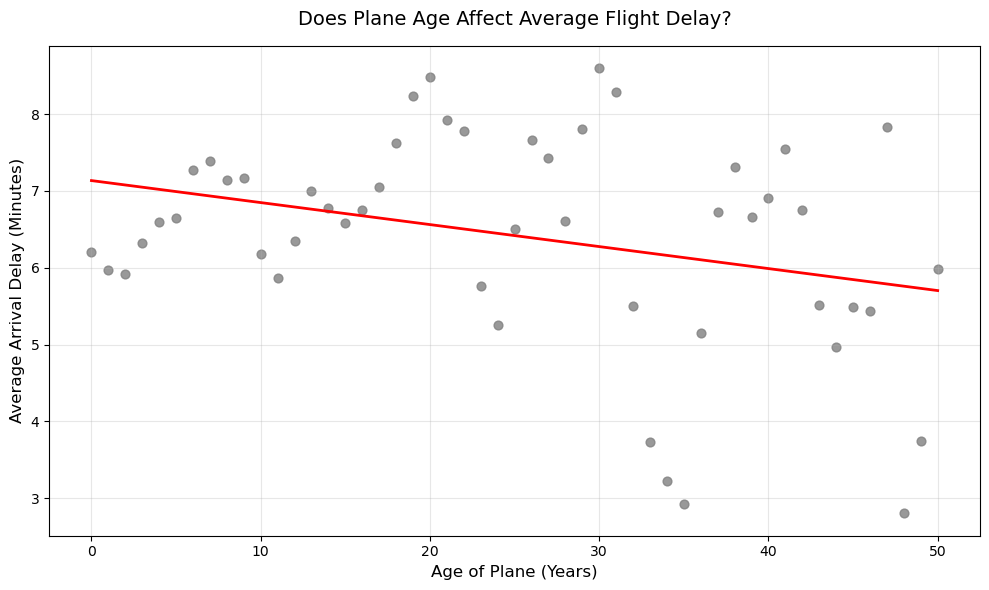

In [5]:
##2b - do older plans suffer more delays
planes_df = pd.read_csv("plane-data.csv")
planes_df = planes_df.rename(columns={'year': 'manufacture_year'}) #avoid confusion
planes_df['manufacture_year'] = pd.to_numeric(planes_df['manufacture_year'], errors='coerce')
planes_df = planes_df.dropna(subset=['manufacture_year'])
planes_df = planes_df[planes_df['manufacture_year']>0]
q2b_data = delay_df.merge(planes_df, left_on='TailNum', right_on='tailnum', how = "inner")
q2b_data['plane_age'] = q2b_data['Year'] - q2b_data['manufacture_year'] 
q2b_data = q2b_data[q2b_data['plane_age'] >= 0] #no negative numbers ya
q2b_overall = q2b_data.groupby('plane_age', observed = False)['ArrDelay'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.regplot(
    data = q2b_overall,
    x='plane_age',
    y='ArrDelay',
    scatter_kws = {'color': 'grey', 's': 40},
    line_kws = {'color': 'red', 'linewidth': 2},
    ci=None
)

plt.title("Does Plane Age Affect Average Flight Delay?", fontsize=14, pad=15)
plt.xlabel("Age of Plane (Years)", fontsize=12)
plt.ylabel("Average Arrival Delay (Minutes)", fontsize=12)
plt.grid(True, alpha=0.3) # Adds a light grid like theme_minimal()
plt.tight_layout()
plt.show()

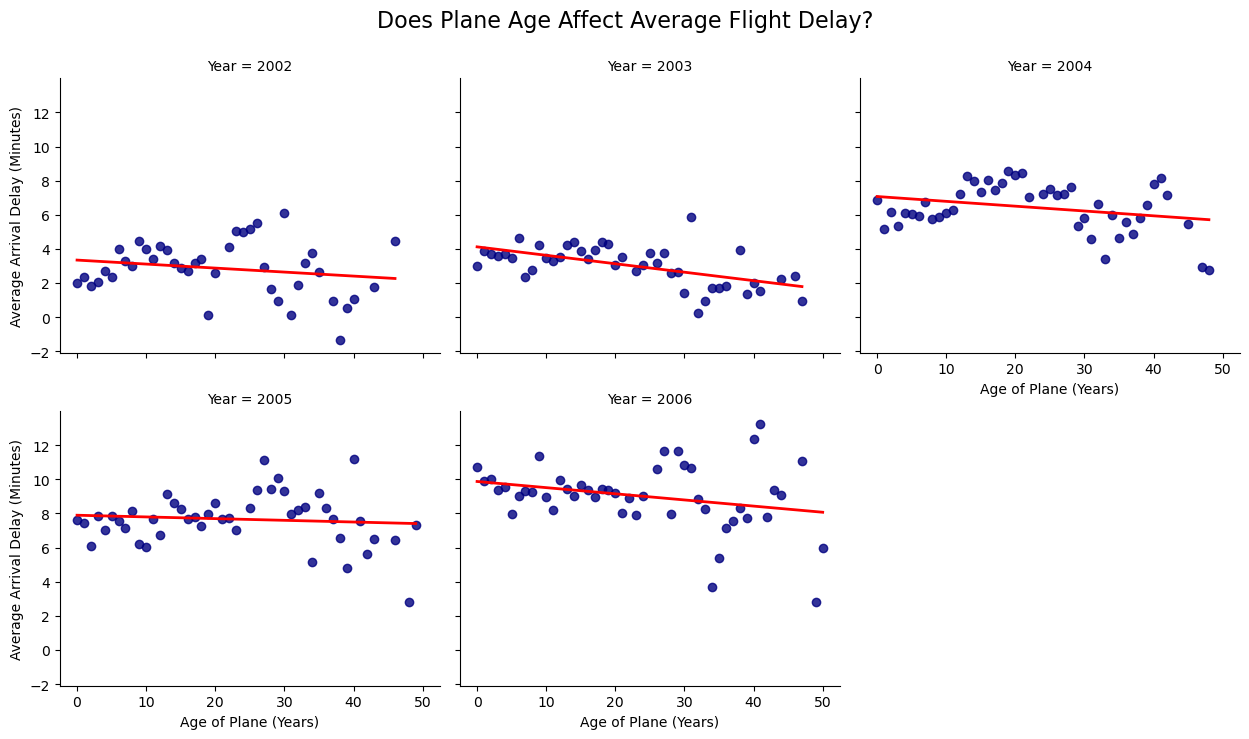

In [7]:
##2b 5 year trend 
q2b_yearly = q2b_data.groupby(['Year', 'plane_age'])['ArrDelay'].mean().reset_index()

# 2. Build the Facet Grid
grid = sns.lmplot(
    data=q2b_yearly,
    x='plane_age',
    y='ArrDelay',
    col='Year',  #by year
    col_wrap=3,         
    height=3.5,
    aspect=1.2,
    scatter_kws={'color': 'navy'},
    line_kws={'color': 'red', 'linewidth': 2},
    ci=None
)

grid.set_axis_labels("Age of Plane (Years)", "Average Arrival Delay (Minutes)")
grid.fig.suptitle("Does Plane Age Affect Average Flight Delay?", y=1.05, fontsize=16)

plt.show()

In [8]:
## part 2c 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import gc  

all_coefs = []

for year in range(2002, 2007):
    print(f"Processing Year: {year}...")
    
    query = f"""
    SELECT 
        o.Diverted, o.Month, o.DayOfWeek, o.CRSDepTime, o.CRSArrTime, o.Distance, o.UniqueCarrier,
        a_orig.lat AS Origin_Lat, a_orig.long AS Origin_Long,
        a_dest.lat AS Dest_Lat, a_dest.long AS Dest_Long
    FROM ontime o
    INNER JOIN airports a_orig ON o.Origin = a_orig.iata
    INNER JOIN airports a_dest ON o.Dest = a_dest.iata
    WHERE o.Year = {year} 
      AND o.Cancelled = 0
      AND o.Diverted IS NOT NULL
      AND a_orig.lat IS NOT NULL 
      AND a_dest.lat IS NOT NULL
    """
    
    yearly_df = pd.read_sql_query(query, conn)
    
    # sample 100k flights 
    if len(yearly_df) > 100000:
        yearly_df = yearly_df.sample(n=100000, random_state=42)
        
    X = yearly_df.drop(columns=['Diverted'])
    #create dummy variables for Carriers
    X = pd.get_dummies(X, columns=['UniqueCarrier'], drop_first=True) 
    y = yearly_df['Diverted']
    
    # train/test Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LogisticRegression(max_iter=1000, solver='liblinear')
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    print(f"Year {year} Model Accuracy: {acc:.4f}")
    
    coef_df = pd.DataFrame({
        'term': X.columns,
        'Estimate': model.coef_[0],
        'Year': year
    })
    all_coefs.append(coef_df)
    
    del yearly_df, X, y, X_train, X_test, y_train, y_test, model
    gc.collect() 
# combining everything into one final master dataframe
final_coefs_df = pd.concat(all_coefs, ignore_index=True)
print("ML Modeling Complete")

Processing Year: 2002...
Year 2002 Model Accuracy: 0.9982
Processing Year: 2003...
Year 2003 Model Accuracy: 0.9982
Processing Year: 2004...
Year 2004 Model Accuracy: 0.9981
Processing Year: 2005...
Year 2005 Model Accuracy: 0.9981
Processing Year: 2006...
Year 2006 Model Accuracy: 0.9974
ML Modeling Complete


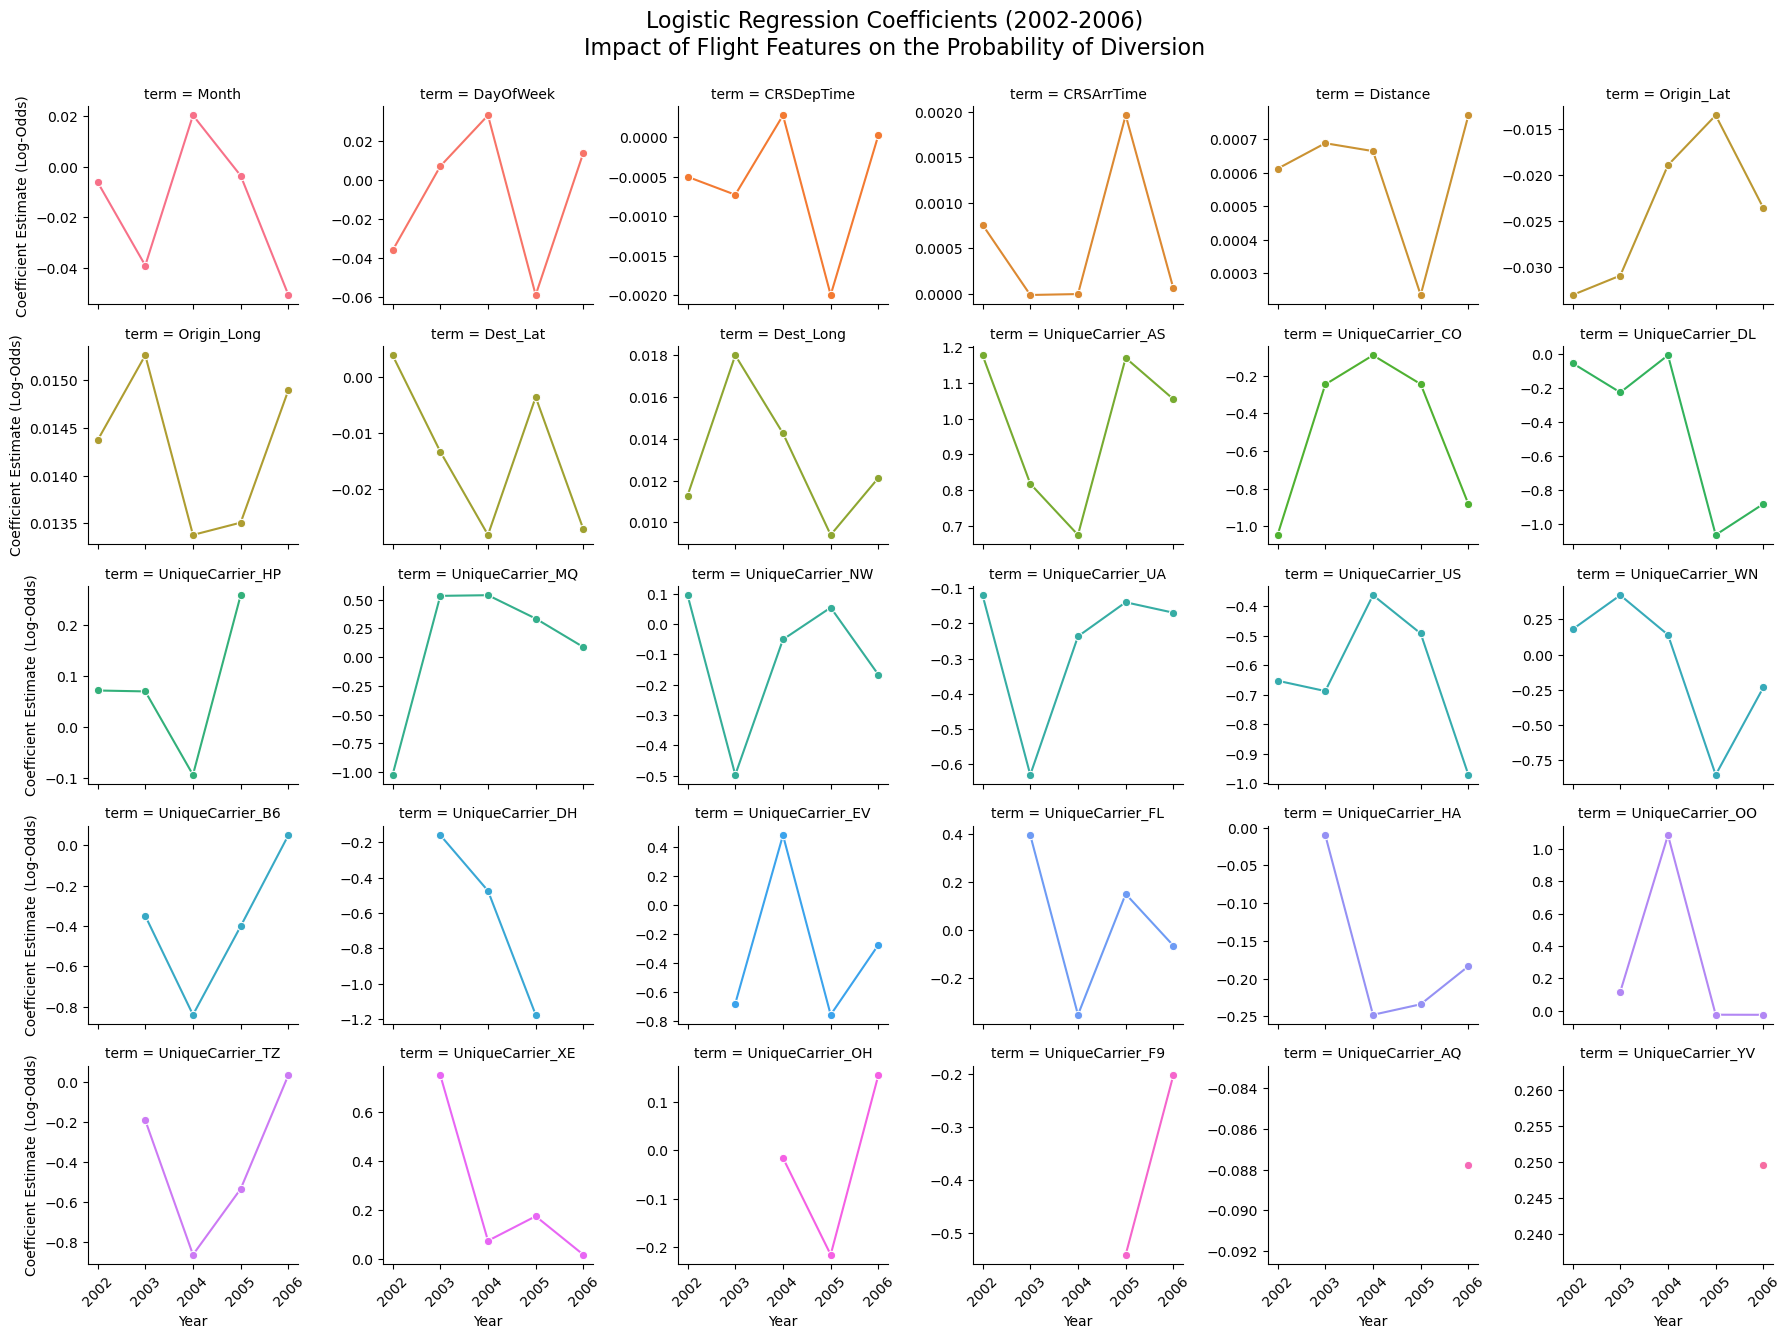

In [10]:
grid_2c = sns.relplot(
    data=final_coefs_df,
    x='Year',
    y='Estimate',
    col='term',
    col_wrap=6,            
    kind='line',
    marker='o', # dots on graph
    hue='term', # each variable = own color
    palette='husl',        
    height=2.5,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': True}, #scales="free_y"
    legend=False
)


grid_2c.set_axis_labels("Year", "Coefficient Estimate (Log-Odds)")
grid_2c.fig.suptitle(
    "Logistic Regression Coefficients (2002-2006)\nImpact of Flight Features on the Probability of Diversion", 
    y=1.05, 
    fontsize=16
)

# x axis = the whole years (2002-2006)
grid_2c.set(xticks=[2002, 2003, 2004, 2005, 2006])
grid_2c.set_xticklabels([2002, 2003, 2004, 2005, 2006], rotation=45)

plt.show()

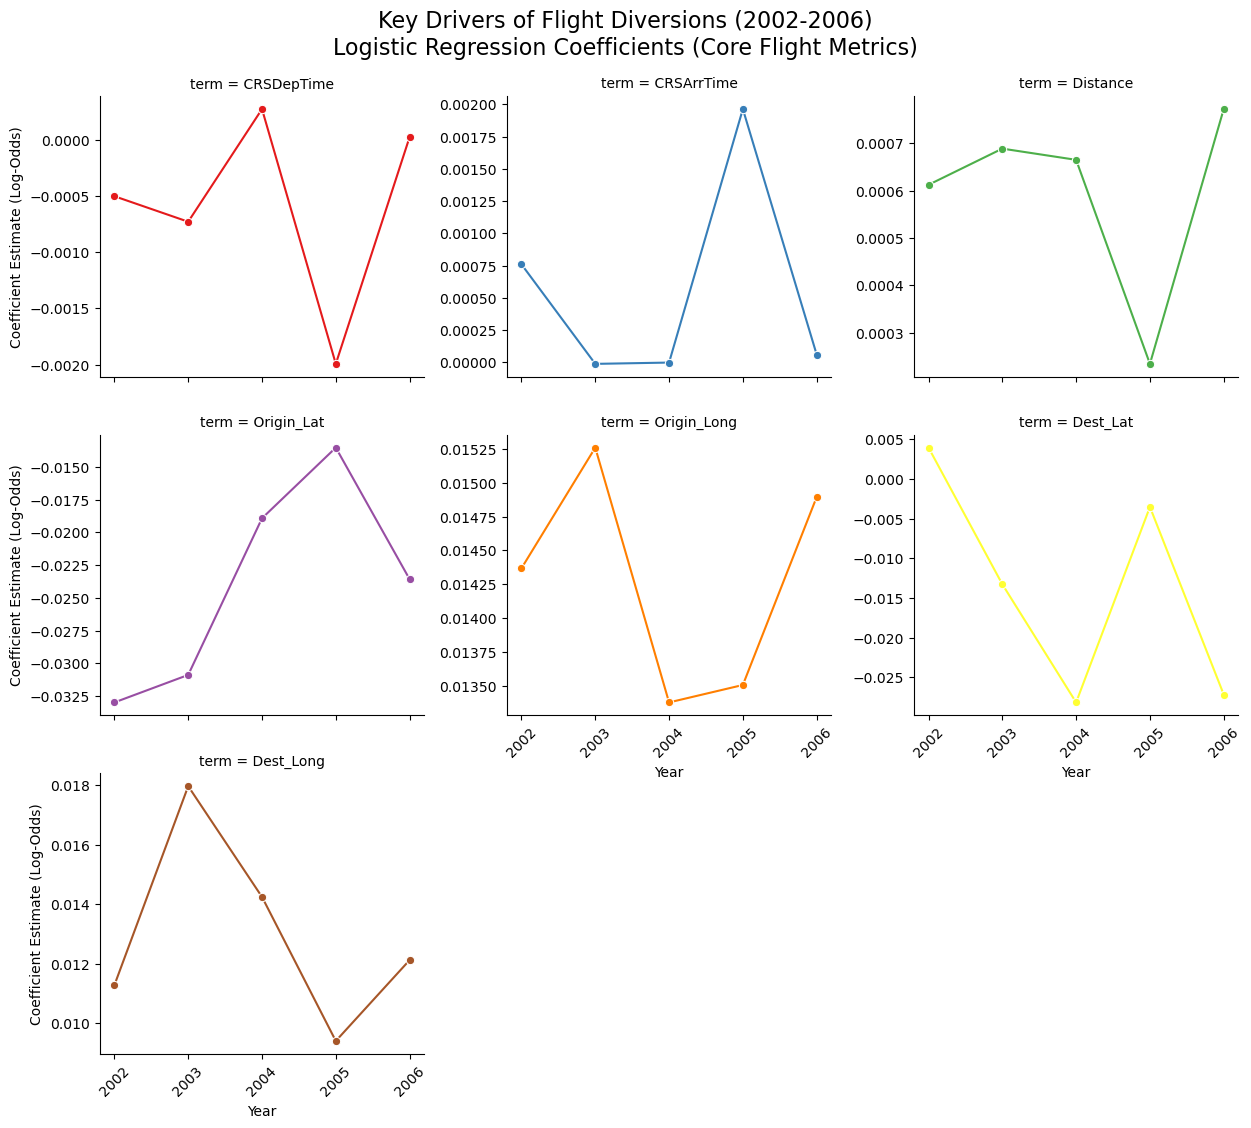

In [11]:
##summary 2c plot
summary_coefs = final_coefs_df[
    ~final_coefs_df['term'].str.contains('UniqueCarrier|DayOfWeek|Month', case=False, na=False)
].copy()

grid_2c_summary = sns.relplot(
    data=summary_coefs,
    x='Year',
    y='Estimate',
    col='term',
    col_wrap=3,
    kind='line',
    marker='o',
    hue='term',
    palette='Set1',      
    height=3.5,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': True}, 
    legend=False
)


grid_2c_summary.set_axis_labels("Year", "Coefficient Estimate (Log-Odds)")
grid_2c_summary.fig.suptitle(
    "Key Drivers of Flight Diversions (2002-2006)\nLogistic Regression Coefficients (Core Flight Metrics)", 
    y=1.05, 
    fontsize=16
)

grid_2c_summary.set(xticks=[2002, 2003, 2004, 2005, 2006])
grid_2c_summary.set_xticklabels([2002, 2003, 2004, 2005, 2006], rotation=45)

plt.show()